In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
import time

In [2]:
df = pd.read_csv('D:\AI&ML\Supervised Learning\Supervised Learning Task\Supervised-Learning\Exam 1\RealEstate Dataset.csv')

In [3]:
df.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


In [4]:
# features
X = df.drop("house_price_inr", axis=1).values

# target
y = df["house_price_inr"].values

In [5]:
X = (X - X.mean(axis=0)) / X.std(axis=0)

In [6]:
m = len(y)

# add column of 1s for bias
X = np.c_[np.ones(m), X]

n = X.shape[1]

# initialize weights
theta = np.zeros(n)

learning_rate = 0.01
epochs = 1000

GRADIENT DESCENT METHOD

In [7]:
for epoch in range(epochs):

    predictions = X.dot(theta)

    gradient = (1/m) * X.T.dot(predictions - y)

    theta = theta - learning_rate * gradient

    if epoch % 100 == 0:
        cost = (1/(2*m)) * np.sum((predictions - y)**2)
        print("Epoch:", epoch, "Cost:", cost)

print("\nFinal Weights:", theta)

Epoch: 0 Cost: 356241692049641.7
Epoch: 100 Cost: 48599805127773.45
Epoch: 200 Cost: 13807958127229.75
Epoch: 300 Cost: 8481202428416.972
Epoch: 400 Cost: 7293054325358.735
Epoch: 500 Cost: 6819456208863.223
Epoch: 600 Cost: 6543895015325.263
Epoch: 700 Cost: 6361073248169.431
Epoch: 800 Cost: 6234338927463.873
Epoch: 900 Cost: 6144443132225.93

Final Weights: [ 2.36408658e+07  5.46006493e+03  7.45568994e+06  1.32246163e+06
  5.74396256e+04  6.44216725e+06 -9.12789275e+05 -1.04814021e+06
  6.81189069e+05  3.81754928e+04  1.22728822e+05 -1.68484942e+05]


COST FUNCTION VS EPOCH GRAPH

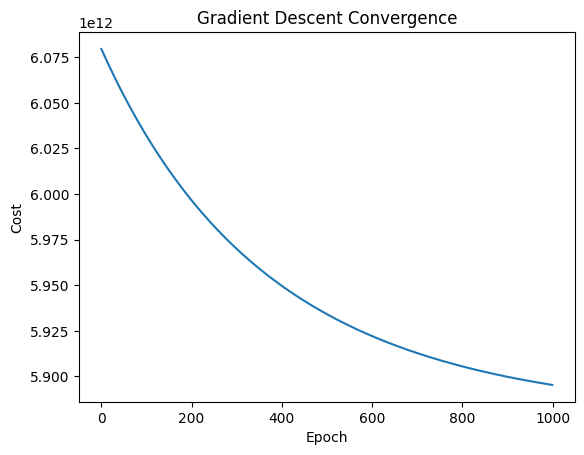

In [8]:
cost_history = []

for epoch in range(epochs):

    predictions = X.dot(theta)
    gradient = (1/m) * X.T.dot(predictions - y)
    theta = theta - learning_rate * gradient

    cost = (1/(2*m)) * np.sum((predictions - y)**2)
    cost_history.append(cost)

import matplotlib.pyplot as plt
plt.plot(cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")
plt.show()

ERROR IN THE MODEL

In [9]:
mse = np.mean((y-predictions))
print("MSE:", mse)

MSE: 0.044507787869799705


In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X[:,1:], y)

print("Sklearn Weights:", model.coef_)
print("Your Weights:", theta[1:])

Sklearn Weights: [  17340.6778608  8776383.99802021  292883.32563156  212865.44175456
 6653544.36067435 -892837.86190362 -814608.55482862  180003.66777692
   72563.4362957   119020.78609421 -174091.44153918]
Your Weights: [  13773.18376708 8408013.48896072  655824.90068742  110928.0443187
 6642777.46625854 -898385.28355595 -833588.45139463  294984.5430163
   58099.38793592  116457.27479325 -172433.61020584]


In [11]:
df.shape

(4200, 12)

Batch Gradient Descent is an optimization algorithm used to minimize the loss function in machine learning models by updating model parameters using the entire training dataset in each iteration. During every epoch, the algorithm calculates the gradient of the cost function with respect to all parameters and updates them in the direction that reduces the error.